In [1]:
import numpy as np
from scipy.integrate import odeint
import pandas as pd
import matplotlib.pyplot as plt

# Example 1: $\exp(-x)\log(t) - t^2$

In [2]:
def fun(x, t):
    return np.exp(-x) * np.log(t) - t**2

# 200 initial conditions
x_0 = np.linspace(0.5,5,200)

# time stamps
deltat = 1/50 
tStop =  2
t = np.arange(0.1, tStop, deltat)

# solve
sol = odeint(fun, x_0, t)

# transpose the solution, each row is a trajectory
data = sol.T

# compute true RHS
true = np.exp(-data) * np.log(t) - t**2

# estimate derivatives using difference  quotient
derivative = np.zeros(data.shape)
col = data.shape[1]
for j in range(col-1):
    # 1st order forward 
    derivative[:,j] = (data[:,j+1] - data[:,j]) / deltat
# 2nd order backward for right endpoint
derivative[:,-1] = (3*data[:,-1] -4 *data[:,-2] + data[:,-3]) / (2*deltat)

In [3]:
# export data
d = pd.DataFrame(data)
d.to_csv('eg1_sol.csv', index=False)

d = pd.DataFrame(true)
d.to_csv('eg1_true_RHS.csv', index=False)

d = pd.DataFrame(derivative)
d.to_csv('eg1_app_RHS.csv', index=False)

# Example 2: $cos(3x) + x^3 - x$

In [2]:
def fun(x, t):
    return np.cos(3*x) + x**3 - x

# 200 initial conditions
x_0 = np.linspace(-0.7,0.9,500)

# time stamps
deltat = 0.04
t = np.arange(0, 1, deltat)

# solve
sol = odeint(fun, x_0, t)

# transpose the solution, each row is a trajectory
data = sol.T

# compute true RHS
true = np.cos(5*data) + data**3 - data

# estimate derivatives using difference  quotient
derivative = np.zeros(data.shape)
col = data.shape[1]
for j in range(col-1):
    # 1st order forward 
    derivative[:,j] = (data[:,j+1] - data[:,j]) / deltat
# 2nd order backward for right endpoint
derivative[:,-1] = (3*data[:,-1] -4 *data[:,-2] + data[:,-3]) / (2*deltat)

In [3]:
# export data
d = pd.DataFrame(data)
d.to_csv('eg2_sol.csv', index=False)

d = pd.DataFrame(true)
d.to_csv('eg2_true_RHS.csv', index=False)

d = pd.DataFrame(derivative)
d.to_csv('eg2_app_RHS.csv', index=False)

# Example 3: $xcos(x)$

In [5]:
def fun(x, t):
    return x*np.cos(x)

# 200 initial conditions
x_0 = np.linspace(-2.5,2.5,500)

# time stamps
deltat = 0.05
t = np.arange(0, 3, deltat)

# solve
sol = odeint(fun, x_0, t)

# transpose the solution, each row is a trajectory
data = sol.T

# compute true RHS
true = data * np.cos(data)

# estimate derivatives using difference  quotient
derivative = np.zeros(data.shape)
col = data.shape[1]
for j in range(col-1):
    # 1st order forward 
    derivative[:,j] = (data[:,j+1] - data[:,j]) / deltat
# 2nd order backward for right endpoint
derivative[:,-1] = (3*data[:,-1] -4 *data[:,-2] + data[:,-3]) / (2*deltat)

In [6]:
# export data
d = pd.DataFrame(data)
d.to_csv('eg3_sol.csv', index=False)

d = pd.DataFrame(true)
d.to_csv('eg3_true_RHS.csv', index=False)

d = pd.DataFrame(derivative)
d.to_csv('eg3_app_RHS.csv', index=False)

# Example 3:

$$ x_1' = x_2 $$
$$ x_2' = \mu(1-x_1^2)x_2 - x_1 $$

In [15]:
def fun(x, t, mu):
    x1, x2 = x
    return [x2, mu * (1-x1**2) * x2 - x1]

mu = 0.02

# initialization
#x_1 = np.linspace(-2.5, 2.5, 400)
#x_2 = np.linspace(-2.5, 2.5, 400)
x_1 = np.random.uniform(-4,4,10)
x_2 = np.random.uniform(-4,4,10)
XX, YY = np.meshgrid(x_1,x_2)
x_0 = np.append(XX.reshape(10**2,1), YY.reshape(10**2,1), axis=1)

# time stamps
deltat = 0.01
t = np.arange(0.14, 5.15, deltat)

# solve iteratively
sol = odeint(fun, x_0[0], t, args=(mu,))

for i in range(1,100):
    sol_new = odeint(fun, x_0[i], t, args=(mu,))
    sol = np.row_stack((sol, sol_new))

In [16]:
x_0.shape

(100, 2)

In [19]:
sol.shape

(50200, 2)

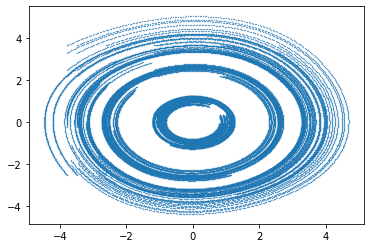

In [18]:
plt.scatter(sol[:,0], sol[:,1], s=0.1)

In [15]:
from scipy.io import loadmat
e3 = loadmat('dataset.mat')

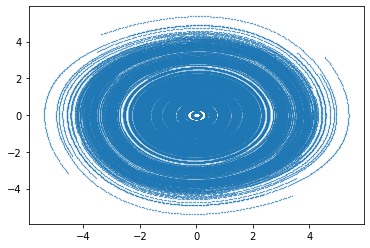

In [122]:
import matplotlib.pyplot as plt
data = e3['X']
plt.scatter(data[:,0], data[:,1], s=0.1)